# AmbiTap — visual tour

A guided walk through the library's signal path — spherical-harmonic encoding,
soundfield rotation, VBAP/decoding, and binaural rendering — with every number
computed by the **actual C++ implementation** through the C ABI
(`tools/capi/`, loaded via ctypes by `ambitap_py.py`; the first cell builds
`libambitap_capi` if it is missing). Cells with `assert`s double as an
executable verification layer: if this notebook runs to the end, the claims in
it hold for the code as built.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import ambitap_py as at

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
PAL = at.PALETTE
info = at.builtin_hrtf_info()
print(f"AmbiTap C ABI loaded — channels(order 3) = {at.channel_count(3)}, "
      f"built-in HRTF: order {info['order']}, {info['length']} taps @ {info['sample_rate']:.0f} Hz")


AmbiTap C ABI loaded — channels(order 3) = 16, built-in HRTF: order 5, 128 taps @ 44100 Hz


## 1. The spherical-harmonic basis (ACN / SN3D)

Each HOA channel carries one basis function $Y_{nm}$. The maps below are
equirectangular views of orders 0–2 (red = positive lobe, blue = negative —
a diverging scale with a neutral midpoint). ACN ordering runs W; Y, Z, X;
V, T, R, S, U.


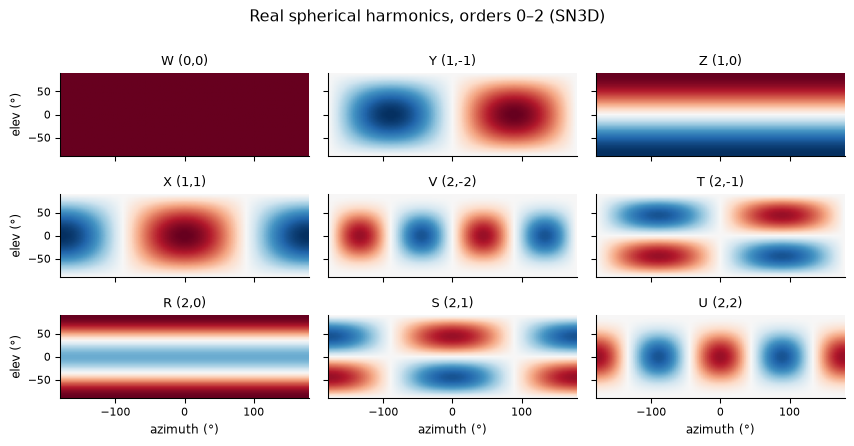

In [2]:
order = 2
az, el, AZ, EL = at.direction_grid(121, 61)
Y = at.sh_matrix(order, AZ.ravel(), EL.ravel())      # computed by the C++ core
maps = Y.T.reshape(-1, *AZ.shape)

names = ["W (0,0)", "Y (1,-1)", "Z (1,0)", "X (1,1)",
         "V (2,-2)", "T (2,-1)", "R (2,0)", "S (2,1)", "U (2,2)"]
vmax = np.abs(maps).max()
fig, axes = plt.subplots(3, 3, figsize=(9, 4.6), sharex=True, sharey=True)
for i, ax in enumerate(axes.ravel()):
    ax.imshow(maps[i], origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax,
              extent=[-180, 180, -90, 90], aspect="auto")
    ax.set_title(names[i]); ax.grid(False)
for ax in axes[-1]: ax.set_xlabel("azimuth (°)")
for row in axes: row[0].set_ylabel("elev (°)")
fig.suptitle("Real spherical harmonics, orders 0–2 (SN3D)", y=1.0)
fig.tight_layout()


In [3]:
# VERIFY: the C++ SH values match an independent SciPy reference
# (associated Legendre via lpmv, Condon-Shortley phase removed, SN3D).
from math import factorial
from scipy.special import lpmv

def sh_ref(order, azimuth, elevation):
    out = np.zeros((order + 1) ** 2)
    s = np.sin(elevation)
    for n in range(order + 1):
        for m in range(-n, n + 1):
            am = abs(m)
            p = float(lpmv(am, n, s)) * ((-1) ** am)
            norm = np.sqrt((1.0 if am == 0 else 2.0) * factorial(n - am) / factorial(n + am))
            v = norm * p
            v *= np.cos(m * azimuth) if m > 0 else (np.sin(am * azimuth) if m < 0 else 1.0)
            out[n * n + n + m] = v
    return out

rng = np.random.default_rng(1)
worst = 0.0
for _ in range(200):
    a = float(rng.uniform(-np.pi, np.pi)); e = float(rng.uniform(-np.pi / 2, np.pi / 2))
    worst = max(worst, np.abs(at.evaluate_sh(5, a, e) - sh_ref(5, a, e)).max())
print(f"max |C++ − SciPy| over 200 random directions, order 5: {worst:.2e}")
assert worst < 2e-5


max |C++ − SciPy| over 200 random directions, order 5: 8.19e-07


## 2. Soundfield rotation

A source encoded at azimuth +45° is rotated −90° (to the right). The maps show
the "virtual microphone" beam $\,b(d) = Y(d) \cdot \mathrm{coeffs}\,$
before and after; the × marks where the source *should* end up.


rotated beam peaks at azimuth -45°


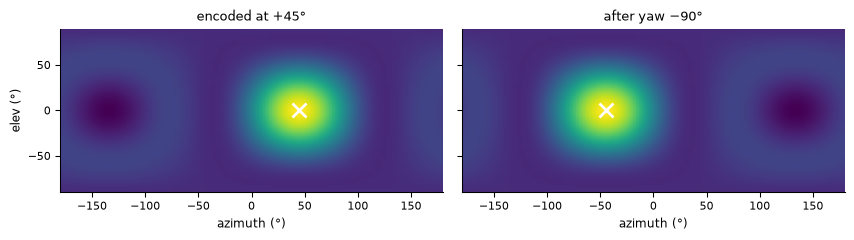

In [4]:
order = 3
src_az = np.radians(45.0)
coeffs = at.evaluate_sh(order, src_az, 0.0)
R = at.sh_rotation_matrix(order, np.radians(-90.0), 0.0, 0.0)
rotated = R @ coeffs

az, el, AZ, EL = at.direction_grid(121, 61)
Y = at.sh_matrix(order, AZ.ravel(), EL.ravel())
fig, axes = plt.subplots(1, 2, figsize=(9, 2.6), sharey=True)
for ax, c, mark_az, title in [(axes[0], coeffs, 45, "encoded at +45°"),
                              (axes[1], rotated, -45, "after yaw −90°")]:
    beam = (Y @ c).reshape(AZ.shape)
    ax.imshow(beam, origin="lower", cmap="viridis",
              extent=[-180, 180, -90, 90], aspect="auto")
    ax.plot(mark_az, 0, "x", color="white", ms=10, mew=2)
    ax.set_title(title); ax.set_xlabel("azimuth (°)"); ax.grid(False)
axes[0].set_ylabel("elev (°)")
fig.tight_layout()

# VERIFY the defining property Y(R·d) == R_sh · Y(d), and the beam peak.
d_rot = at.evaluate_sh(order, np.radians(-45.0), 0.0)
assert np.abs(rotated - d_rot).max() < 2e-4
beam = (Y @ rotated).reshape(AZ.shape)
peak_az = np.degrees(az[np.unravel_index(beam.argmax(), beam.shape)[1]])
print(f"rotated beam peaks at azimuth {peak_az:+.0f}°")
assert abs(peak_az - (-45)) < 4


## 3. VBAP panning

Gains per speaker as a source sweeps the horizon. The cube (a genuinely 3D
layout) uses triangle-based 3D VBAP; 5.1 is planar, so the layout switches to
2D **pairwise** panning — the classic constant-energy crossfades between
adjacent speakers. Every gain vector satisfies $\sum g^2 = 1$.


VBAP gain vectors are energy-normalized on both layouts ✓


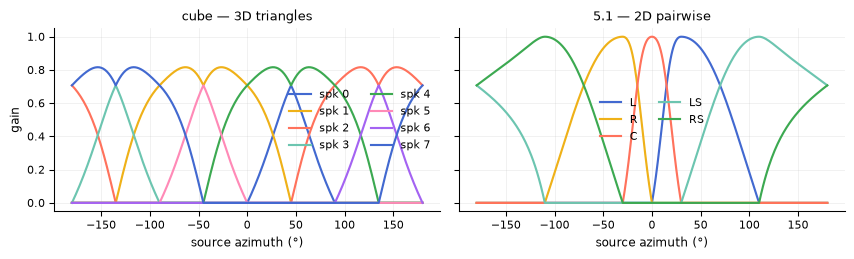

In [5]:
sweep = np.radians(np.linspace(-180, 180, 361))
fig, axes = plt.subplots(1, 2, figsize=(9, 2.8), sharex=True, sharey=True)
for ax, name, labels in [
    (axes[0], "cube", [f"spk {i}" for i in range(8)]),
    (axes[1], "5.1", ["L", "R", "C", "LS", "RS"]),
]:
    az_s, el_s = at.layout(name)
    G = np.stack([at.vbap_gains(az_s, el_s, float(a), 0.0) for a in sweep])
    assert np.allclose((G ** 2).sum(axis=1), 1.0, atol=1e-3)   # energy-normalized
    for i in range(G.shape[1]):
        ax.plot(np.degrees(sweep), G[:, i], color=PAL[i % len(PAL)], lw=1.6,
                label=labels[i])
    ax.set_title(f"{name} — {'3D triangles' if name == 'cube' else '2D pairwise'}")
    ax.set_xlabel("source azimuth (°)")
    ax.legend(ncol=2, frameon=False)
axes[0].set_ylabel("gain")
fig.tight_layout()
print("VBAP gain vectors are energy-normalized on both layouts ✓")


## 4. Binaural rendering

A 330 Hz tone orbiting the head once per two seconds, rendered through
encoder → HRTF convolution at 48 kHz (the 44.1 kHz KEMAR FIRs are resampled
by `prepare()`). The short-time level shows the source sweeping between the
ears; listen with headphones.


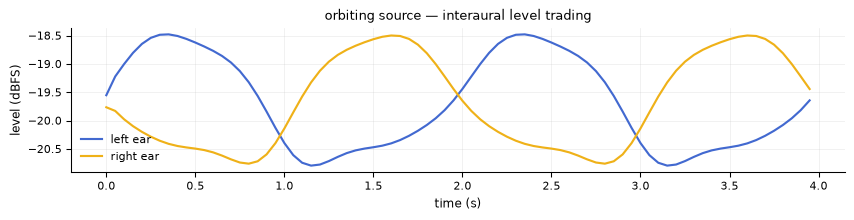

In [6]:
fs, seconds = 48000, 4
n = fs * seconds
t = np.arange(n)
mono = (0.5 * np.sin(2 * np.pi * 330 * t / fs)).astype(np.float32)
az_traj = (2 * np.pi * t / (2 * fs)).astype(np.float32)     # one orbit / 2 s
left, right = at.binaural_render(mono, az_traj, np.zeros(n, np.float32),
                                 order=3, sample_rate=fs, magls=True)

win = fs // 20
rms = lambda x: np.sqrt((x[: len(x) // win * win].reshape(-1, win) ** 2).mean(axis=1))
tt = np.arange(len(rms(left))) * win / fs
fig, ax = plt.subplots(figsize=(9, 2.4))
ax.plot(tt, 20 * np.log10(rms(left) + 1e-9), color=PAL[0], lw=1.6, label="left ear")
ax.plot(tt, 20 * np.log10(rms(right) + 1e-9), color=PAL[1], lw=1.6, label="right ear")
ax.set_xlabel("time (s)"); ax.set_ylabel("level (dBFS)")
ax.set_title("orbiting source — interaural level trading")
ax.legend(frameon=False)
fig.tight_layout()

assert np.isfinite(left).all() and np.isfinite(right).all()
assert np.sqrt((left ** 2).mean()) > 0.01 and np.abs(left - right).max() > 0.01

from IPython.display import Audio
Audio(np.stack([left, right]), rate=fs)
